### NFSP-FQI

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# NFSP Agent class
class NFSPAgent:
    def __init__(self, agent_id, state_size=1, action_size=50, hidden_size=64,
                 lr_q=0.001, lr_pi=0.001, epsilon_start=1.0, epsilon_end=0.1,
                 epsilon_decay=0.999, anticipatory_param=0.1,
                 rl_memory_capacity=10000, sl_memory_capacity=10000):
        self.agent_id = agent_id
        self.state_size = state_size
        self.hidden_size = hidden_size
        self.action_size = action_size
        self.lr_q = lr_q
        self.lr_pi = lr_pi
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.eta = anticipatory_param
        self.device = device
        self.action_space = np.linspace(0, 1, action_size)
        
        # Q-Network and optimizer
        self.q_network = self.build_network()
        self.q_optimizer = optim.Adam(self.q_network.parameters(), lr=self.lr_q)
        self.q_loss_fn = nn.MSELoss()
        
        # Policy Network and optimizer
        self.policy_network = self.build_network()
        self.policy_optimizer = optim.Adam(self.policy_network.parameters(), lr=self.lr_pi)
        self.policy_loss_fn = nn.CrossEntropyLoss()
        
        # Replay Memories
        self.rl_memory = []  # For Q-learning
        self.rl_memory_capacity = rl_memory_capacity
        self.sl_memory = []  # For supervised learning
        self.sl_memory_capacity = sl_memory_capacity
        
        # Reservoir sampling counters
        self.sl_memory_counter = 0
        
    def build_network(self):
        # Adjust the output layer size to action_size
        model = nn.Sequential(
            nn.Linear(self.state_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.action_size)
        ).to(self.device)
        return model

    def select_action(self, state):
        # print(f"Agent {self.agent_id}: Selecting action for state {state}")
        # Decide whether to use the policy network or ε-greedy Q-network
        if random.random() < self.eta:
            # Use policy network
            state_tensor = torch.FloatTensor([[state]]).to(self.device)  # Shape: (1, 1)
            with torch.no_grad():
                logits = self.policy_network(state_tensor)
                probabilities = nn.functional.softmax(logits, dim=-1)
                action_index = torch.multinomial(probabilities, 1).item()
            action = self.action_space[action_index]
            # print(f"Agent {self.agent_id}: Using policy network, action_index {action_index}, action {action}")
        else:
            # Use ε-greedy policy from Q-network
            if random.random() < self.epsilon:
                action_index = random.randint(0, self.action_size - 1)
                # print(f"Agent {self.agent_id}: Random action_index {action_index}")
            else:
                state_tensor = torch.FloatTensor([[state]]).to(self.device)
                with torch.no_grad():
                    q_values = self.q_network(state_tensor)
                    action_index = torch.argmax(q_values).item()
                # print(f"Agent {self.agent_id}: Using Q-network, action_index {action_index}")
            action = self.action_space[action_index]
            # Store state-action pair for supervised learning
            self.store_sl_memory(state, action_index)
        return action, action_index

    def store_rl_memory(self, state, action_index, reward, next_state):
        if len(self.rl_memory) >= self.rl_memory_capacity:
            self.rl_memory.pop(0)
        self.rl_memory.append((state, action_index, reward, next_state))

    def store_sl_memory(self, state, action_index):
        # Reservoir sampling
        self.sl_memory_counter += 1
        if len(self.sl_memory) < self.sl_memory_capacity:
            self.sl_memory.append((state, action_index))
        else:
            replace_index = random.randint(0, self.sl_memory_counter - 1)
            if replace_index < self.sl_memory_capacity:
                self.sl_memory[replace_index] = (state, action_index)

    def train_q_network(self, batch_size=32):
        if len(self.rl_memory) < batch_size:
            return
        batch = random.sample(self.rl_memory, batch_size)
        states, action_indices, rewards, next_states = zip(*batch)
        states_tensor = torch.FloatTensor(states).unsqueeze(1).to(self.device)  # Shape: (batch_size, 1)
        action_indices_tensor = torch.LongTensor(action_indices).to(self.device)  # Shape: (batch_size,)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)  # Shape: (batch_size,)
        next_states_tensor = torch.FloatTensor(next_states).unsqueeze(1).to(self.device)  # Shape: (batch_size, 1)

        # print(f"Agent {self.agent_id}: Training Q-network with batch_size {batch_size}")
        # print(f"states_tensor shape: {states_tensor.shape}")
        # print(f"action_indices_tensor shape: {action_indices_tensor.shape}")
        # print(f"rewards_tensor shape: {rewards_tensor.shape}")
        # print(f"next_states_tensor shape: {next_states_tensor.shape}")

        # Compute Q targets
        with torch.no_grad():
            q_next = self.q_network(next_states_tensor)
            max_q_next, _ = torch.max(q_next, dim=1)
            q_targets = rewards_tensor + 0.0 * max_q_next  # gamma=0

        q_values = self.q_network(states_tensor)
        q_values = q_values.gather(1, action_indices_tensor.unsqueeze(1)).squeeze()

        loss = self.q_loss_fn(q_values, q_targets)
        # print(f"Agent {self.agent_id}: Q-network loss {loss.item()}")
        self.q_optimizer.zero_grad()
        loss.backward()
        self.q_optimizer.step()

        # Decay epsilon
        if self.epsilon > self.epsilon_end:
            self.epsilon *= self.epsilon_decay

    def train_policy_network(self, batch_size=32):
        if len(self.sl_memory) < batch_size:
            return
        batch = random.sample(self.sl_memory, batch_size)
        states, action_indices = zip(*batch)
        states_tensor = torch.FloatTensor(states).unsqueeze(1).to(self.device)
        action_indices_tensor = torch.LongTensor(action_indices).to(self.device)

        # print(f"Agent {self.agent_id}: Training policy network with batch_size {batch_size}")
        # print(f"states_tensor shape: {states_tensor.shape}")
        # print(f"action_indices_tensor shape: {action_indices_tensor.shape}")

        logits = self.policy_network(states_tensor)
        loss = self.policy_loss_fn(logits, action_indices_tensor)
        # print(f"Agent {self.agent_id}: Policy network loss {loss.item()}")
        self.policy_optimizer.zero_grad()
        loss.backward()
        self.policy_optimizer.step()

# training loop
def training_loop(env, agents, num_episodes, num_episodes_track, num_agents): 
    for episode in range(num_episodes):
        # Reset environment
        valuations = env.reset()
        states = valuations  # For this simple environment, state is valuation
    
        # Agents select actions
        bids = []
        action_indices = []
        for i, agent in enumerate(agents):
            action, action_index = agent.select_action(states[i])
            bids.append(action)
            action_indices.append(action_index)
    
        bids = np.array(bids)
        # Step the environment
        next_states, rewards, done, info = env.step(bids)
    
        # Agents observe rewards and store transitions
        for i, agent in enumerate(agents):
            agent.store_rl_memory(states[i], action_indices[i], rewards[i], next_states[i])
            # Train Q-network and Policy network
            agent.train_q_network()
            agent.train_policy_network()
    
        # Optionally, print progress
        if (episode + 1) % num_episodes_track == 0:
            print(f"Episode {episode + 1}/{num_episodes}")
    return agents

# Evaluation and plotting
def evaluate_agents(agents, num_evaluations=1000, num_agents=3):
    env = FirstPriceAuctionEnv(num_agents=num_agents)
    total_rewards = np.zeros(num_agents)
    for _ in range(num_evaluations):
        valuations = env.reset()
        states = valuations
        bids = []
        for i, agent in enumerate(agents):
            # Use policy network for evaluation
            state_tensor = torch.FloatTensor([[states[i]]]).to(agent.device)
            with torch.no_grad():
                logits = agent.policy_network(state_tensor)
                probabilities = nn.functional.softmax(logits, dim=-1)
                action_index = torch.argmax(probabilities).item()
                action = agent.action_space[action_index]
            bids.append(action)
        bids = np.array(bids)
        _, rewards, _, _ = env.step(bids)
        total_rewards += rewards
    avg_rewards = total_rewards / num_evaluations
    print(f"Average Rewards: {avg_rewards}")

def plot_bidding_policies(agents, optimal_bidding_rule, num_agents):
    valuations = np.linspace(0, 1, 100)
    for i, agent in enumerate(agents):
        bids = []
        for v in valuations:
            state_tensor = torch.FloatTensor([[v]]).to(agent.device)
            with torch.no_grad():
                logits = agent.policy_network(state_tensor)
                probabilities = nn.functional.softmax(logits, dim=-1)
                action_index = torch.argmax(probabilities).item()
                action = agent.action_space[action_index]
            bids.append(action)
        plt.plot(valuations, bids, label=f'Agent {i+1}')
        
    # Plot optimal bidding strategy for first-price auction
    n = env.num_agents
    optimal_bids = optimal_bidding_rule(valuations, num_agents)
    plt.plot(valuations, optimal_bids, label='Optimal Bid', linestyle='--')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.title('Learned Bidding Policies')
    plt.legend()
    plt.show()

Using device: cpu


In [1]:
# Environment definition
class FirstPriceAuctionEnv:
    def __init__(self, num_agents=2):
        self.num_agents = num_agents

    def reset(self):
        # Each agent gets a private valuation drawn uniformly from [0, 1]
        self.valuations = np.random.uniform(0, 1, size=self.num_agents)
        return self.valuations

    def step(self, bids):
        # Determine the winner
        max_bid = np.max(bids)
        winners = np.where(bids == max_bid)[0]
        # If tie, select winner randomly among highest bidders
        winner = np.random.choice(winners)
        # Calculate rewards
        rewards = np.zeros(self.num_agents)
        rewards[winner] = self.valuations[winner] - bids[winner]
        # Observations are the same as valuations for this simple environment
        next_state = self.valuations
        done = True  # Single-step episode
        info = {'winner': winner, 'bids': bids}
        return next_state, rewards, done, info

def FirstPriceAuctionOptimalBid(valuations, num_agents):
    return (num_agents-1)/num_agents * valuations

# Training Loop
num_episodes = 10000
num_episodes_track = 500
num_agents = 3
env = FirstPriceAuctionEnv(num_agents=num_agents)
agents = [NFSPAgent(agent_id=i, action_size=50) for i in range(num_agents)]  # Increase action_size for better resolution
agents = training_loop(env, agents, num_episodes, num_episodes_track, num_agents)
evaluate_agents(agents, num_evaluations=1000, num_agents=num_agents)
plot_bidding_policies(agents, FirstPriceAuctionOptimalBid, num_agents)

NameError: name 'NFSPAgent' is not defined

Episode 500/5000
Episode 1000/5000
Episode 1500/5000
Episode 2000/5000
Episode 2500/5000
Episode 3000/5000
Episode 3500/5000
Episode 4000/5000
Episode 4500/5000
Episode 5000/5000
Average Rewards: [-0.01277317  0.00892985  0.01391838]


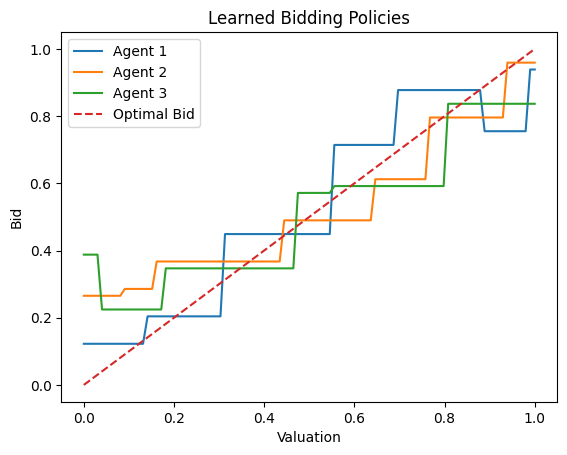

In [11]:
# Environment definition
class SecondPriceAuctionEnv:
    def __init__(self, num_agents=2):
        self.num_agents = num_agents

    def reset(self):
        # Each agent gets a private valuation drawn uniformly from [0, 1]
        self.valuations = np.random.uniform(0, 1, size=self.num_agents)
        return self.valuations

    def step(self, bids):
        # Determine the winner
        max_bid = np.max(bids)
        winners = np.where(bids == max_bid)[0]
        winner = np.random.choice(winners)
        # Second-highest bid
        second_highest_bid = np.sort(bids)[-2]
        # Calculate rewards
        rewards = np.zeros(self.num_agents)
        rewards[winner] = self.valuations[winner] - second_highest_bid
        next_state = self.valuations
        done = True
        info = {'winner': winner, 'bids': bids}
        return next_state, rewards, done, info

# Optimal bid for second-price auction (truthful bidding)
def SecondPriceAuctionOptimalBid(valuations, num_agents):
    return valuations  # Truthful bidding is optimal in second-price auctions

# Training Loop
num_episodes = 5000
num_episodes_track = 500
num_agents = 3
env = SecondPriceAuctionEnv(num_agents=num_agents)
agents = [NFSPAgent(agent_id=i, action_size=50) for i in range(num_agents)]  # Increase action_size for better resolution
agents = training_loop(env, agents, num_episodes, num_episodes_track, num_agents)
evaluate_agents(agents, num_evaluations=1000, num_agents=num_agents)
plot_bidding_policies(agents, SecondPriceAuctionOptimalBid, num_agents)

Episode 500/5000
Episode 1000/5000
Episode 1500/5000
Episode 2000/5000
Episode 2500/5000
Episode 3000/5000
Episode 3500/5000
Episode 4000/5000
Episode 4500/5000
Episode 5000/5000
Average Rewards: [0.07456665 0.06561349 0.06918423]


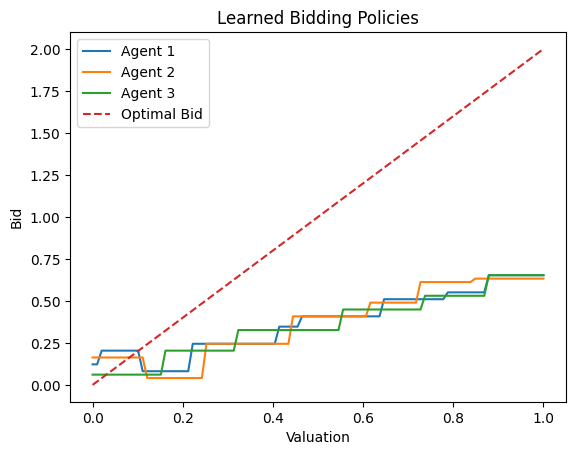

In [13]:
# Environment definition
class KthPriceAuctionEnv:
    def __init__(self, num_agents=2, k=2):
        self.num_agents = num_agents
        self.k = k

    def reset(self):
        # Each agent gets a private valuation drawn uniformly from [0, 1]
        self.valuations = np.random.uniform(0, 1, size=self.num_agents)
        return self.valuations

    def step(self, bids):
        # Determine the winner
        max_bid = np.max(bids)
        winners = np.where(bids == max_bid)[0]
        winner = np.random.choice(winners)
        # Kth-highest bid
        sorted_bids = np.sort(bids)
        kth_highest_bid = sorted_bids[min(self.k - 1, self.num_agents - 1)]  # Ensure k <= num_agents
        # Calculate rewards
        rewards = np.zeros(self.num_agents)
        rewards[winner] = self.valuations[winner] - kth_highest_bid
        next_state = self.valuations
        done = True
        info = {'winner': winner, 'bids': bids}
        return next_state, rewards, done, info

# Optimal bid for kth-price auction (simplified approximation)
def KthPriceAuctionOptimalBid(valuations, num_agents, k=3):
    return valuations * (num_agents - 1) / (num_agents - k + 1)


# Training Loop
num_episodes = 5000
num_episodes_track = 500
num_agents = 3
env = KthPriceAuctionEnv(num_agents=num_agents, k = 3)
agents = [NFSPAgent(agent_id=i, action_size=50) for i in range(num_agents)]  # Increase action_size for better resolution
agents = training_loop(env, agents, num_episodes, num_episodes_track, num_agents)
evaluate_agents(agents, num_evaluations=1000, num_agents=num_agents)
plot_bidding_policies(agents, KthPriceAuctionOptimalBid, num_agents)

Episode 500/5000
Episode 1000/5000
Episode 1500/5000
Episode 2000/5000
Episode 2500/5000
Episode 3000/5000
Episode 3500/5000
Episode 4000/5000
Episode 4500/5000
Episode 5000/5000
Average Rewards: [0.21237101 0.19415636]


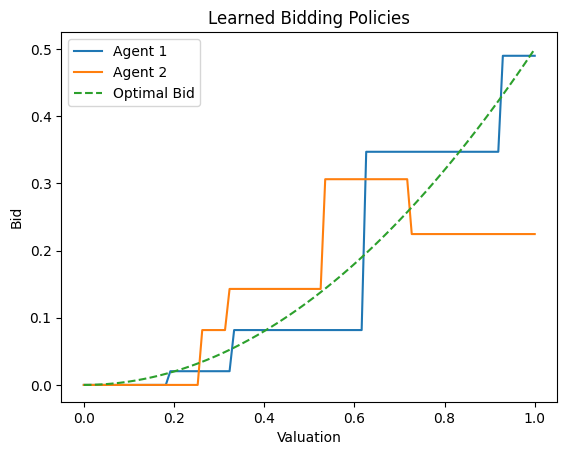

In [14]:
# Environment definition
class AllPayAuctionEnv:
    def __init__(self, num_agents=2):
        self.num_agents = num_agents

    def reset(self):
        # Each agent gets a private valuation drawn uniformly from [0, 1]
        self.valuations = np.random.uniform(0, 1, size=self.num_agents)
        return self.valuations

    def step(self, bids):
        # Determine the winner
        max_bid = np.max(bids)
        winners = np.where(bids == max_bid)[0]
        winner = np.random.choice(winners)
        # Calculate rewards
        rewards = np.zeros(self.num_agents)
        rewards[:] = -bids  # Everyone pays their bid
        rewards[winner] += self.valuations[winner]  # Winner gets their valuation
        next_state = self.valuations
        done = True
        info = {'winner': winner, 'bids': bids}
        return next_state, rewards, done, info

# Optimal bid for all-pay auction (simplified approximation)
def AllPayAuctionOptimalBid(valuations, num_agents):
    return (valuations ** num_agents) / num_agents  # Approximation based on risk-neutral behavior

# Training Loop
num_episodes = 5000
num_episodes_track = 500
num_agents = 2
env = AllPayAuctionEnv(num_agents=num_agents)
agents = [NFSPAgent(agent_id=i, action_size=50) for i in range(num_agents)]  # Increase action_size for better resolution
agents = training_loop(env, agents, num_episodes, num_episodes_track, num_agents)
evaluate_agents(agents, num_evaluations=1000, num_agents=num_agents)
plot_bidding_policies(agents, AllPayAuctionOptimalBid, num_agents)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Environment definition
class KoreanAuctionEnv:
    def __init__(self, num_agents=2):
        self.num_agents = num_agents

    def reset(self):
        # Each agent gets a private valuation drawn uniformly from [0, 1]
        self.valuations = np.random.uniform(0, 1, size=self.num_agents)
        # Initial signal x = 0 for all agents
        self.signals = np.zeros(self.num_agents, dtype=int)
        self.round = 0
        return self._get_states()

    def _get_states(self):
        # Combine valuations and signals to form the state
        # Each state is a tuple (valuation, signal)
        states = [(self.valuations[i], self.signals[i]) for i in range(self.num_agents)]
        return states

    def step(self, bids):
        if self.round == 0:
            # First round logic
            max_bid = np.max(bids)
            epsilon = 1e-6
            is_max_bid = np.isclose(bids, max_bid, atol=epsilon)
            highest_bidders = np.where(is_max_bid)[0]
            
            # Check if all bidders tie for the highest bid
            if len(highest_bidders) == self.num_agents:
                # All bidders have the highest bid, set x = 2 for all
                self.signals[:] = 2
            else:
                # Assign signals based on bids
                for i in range(self.num_agents):
                    if i in highest_bidders:
                        self.signals[i] = 2  # Holds the highest bid
                    else:
                        self.signals[i] = 1  # Does not hold the highest bid
            
            # No rewards in the first round
            rewards = np.zeros(self.num_agents)
            done = False
            self.round += 1
            return self._get_states(), rewards, done, {}
        
        elif self.round == 1:
            # Second round logic (First-Price Auction)
            max_bid = np.max(bids)
            epsilon = 1e-6
            is_max_bid = np.isclose(bids, max_bid, atol=epsilon)
            highest_bidders = np.where(is_max_bid)[0]
            # If tie, select winner randomly among highest bidders
            winner = np.random.choice(highest_bidders)
            # Calculate rewards
            rewards = np.zeros(self.num_agents)
            rewards[winner] = self.valuations[winner] - bids[winner]
            done = True  # Episode ends after second round
            self.round += 1
            return self._get_states(), rewards, done, {'winner': winner, 'bids': bids}
        else:
            raise Exception("Auction has already ended. Please reset the environment.")

# NFSP Agent class
class NFSPAgent:
    def __init__(self, agent_id, state_size=2, action_size=50, hidden_size=64,
                 lr_q=0.001, lr_pi=0.001, epsilon_start=1.0, epsilon_end=0.1,
                 epsilon_decay=0.999, anticipatory_param=0.1,
                 rl_memory_capacity=10000, sl_memory_capacity=10000):
        self.agent_id = agent_id
        self.state_size = state_size  # Now state_size = 2 (valuation, signal)
        self.hidden_size = hidden_size
        self.action_size = action_size
        self.lr_q = lr_q
        self.lr_pi = lr_pi
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.eta = anticipatory_param
        self.device = device
        self.action_space = np.linspace(0, 1, action_size)
        
        # Q-Networks and optimizers for each round
        self.q_networks = [self.build_network() for _ in range(2)]
        self.q_optimizers = [optim.Adam(q_net.parameters(), lr=self.lr_q) for q_net in self.q_networks]
        self.q_loss_fn = nn.MSELoss()
        
        # Policy Networks and optimizers for each round
        self.policy_networks = [self.build_network() for _ in range(2)]
        self.policy_optimizers = [optim.Adam(pi_net.parameters(), lr=self.lr_pi) for pi_net in self.policy_networks]
        self.policy_loss_fn = nn.CrossEntropyLoss()
        
        # Replay Memories for each round
        self.rl_memory = [[] for _ in range(2)]  # For Q-learning
        self.rl_memory_capacity = rl_memory_capacity
        self.sl_memory = [[] for _ in range(2)]  # For supervised learning
        self.sl_memory_capacity = sl_memory_capacity
        
        # Reservoir sampling counters
        self.sl_memory_counter = [0, 0]
        
    def build_network(self):
        # Adjust the input size to state_size (2)
        model = nn.Sequential(
            nn.Linear(self.state_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.action_size)
        ).to(self.device)
        return model

    def select_action(self, state, round_number):
        valuation, signal = state
        
        # Ensure correct signal usage
        if round_number == 0:
            signal = 0  # All agents have x = 0 in round 0
    
        state_tensor = torch.FloatTensor([[valuation, signal]]).to(self.device)  # Shape: (1, 2)
        
        if random.random() < self.eta:
            # Use policy network
            with torch.no_grad():
                logits = self.policy_networks[round_number](state_tensor)
                probabilities = nn.functional.softmax(logits, dim=-1)
                action_index = torch.multinomial(probabilities, 1).item()
            action = self.action_space[action_index]
        else:
            # Use ε-greedy policy from Q-network
            if random.random() < self.epsilon:
                action_index = random.randint(0, self.action_size - 1)
            else:
                with torch.no_grad():
                    q_values = self.q_networks[round_number](state_tensor)
                    action_index = torch.argmax(q_values).item()
            action = self.action_space[action_index]
            # Store state-action pair for supervised learning
            self.store_sl_memory(state, action_index, round_number)
            
        return action, action_index
    

    def store_rl_memory(self, state, action_index, reward, next_state, round_number):
        if len(self.rl_memory[round_number]) >= self.rl_memory_capacity:
            self.rl_memory[round_number].pop(0)
        self.rl_memory[round_number].append((state, action_index, reward, next_state))

    def store_sl_memory(self, state, action_index, round_number):
        # Reservoir sampling
        self.sl_memory_counter[round_number] += 1
        if len(self.sl_memory[round_number]) < self.sl_memory_capacity:
            self.sl_memory[round_number].append((state, action_index))
        else:
            replace_index = random.randint(0, self.sl_memory_counter[round_number] - 1)
            if replace_index < self.sl_memory_capacity:
                self.sl_memory[round_number][replace_index] = (state, action_index)

    def train_q_network(self, batch_size=32, round_number=0):
        if len(self.rl_memory[round_number]) < batch_size:
            return
        batch = random.sample(self.rl_memory[round_number], batch_size)
        states, action_indices, rewards, next_states = zip(*batch)
        states_tensor = torch.FloatTensor(states).to(self.device)  # Shape: (batch_size, 2)
        action_indices_tensor = torch.LongTensor(action_indices).to(self.device)  # Shape: (batch_size,)
        rewards_tensor = torch.FloatTensor(rewards).to(self.device)  # Shape: (batch_size,)
        next_states_tensor = torch.FloatTensor(next_states).to(self.device)  # Shape: (batch_size, 2)

        # Compute Q targets
        with torch.no_grad():
            q_next = self.q_networks[round_number](next_states_tensor)
            max_q_next, _ = torch.max(q_next, dim=1)
            q_targets = rewards_tensor + 0.0 * max_q_next  # gamma=0

        q_values = self.q_networks[round_number](states_tensor)
        q_values = q_values.gather(1, action_indices_tensor.unsqueeze(1)).squeeze()

        loss = self.q_loss_fn(q_values, q_targets)
        self.q_optimizers[round_number].zero_grad()
        loss.backward()
        self.q_optimizers[round_number].step()

        # Decay epsilon
        if self.epsilon > self.epsilon_end:
            self.epsilon *= self.epsilon_decay

    def train_policy_network(self, batch_size=32, round_number=0):
        if len(self.sl_memory[round_number]) < batch_size:
            return
        batch = random.sample(self.sl_memory[round_number], batch_size)
        states, action_indices = zip(*batch)
        states_tensor = torch.FloatTensor(states).to(self.device)
        action_indices_tensor = torch.LongTensor(action_indices).to(self.device)

        logits = self.policy_networks[round_number](states_tensor)
        loss = self.policy_loss_fn(logits, action_indices_tensor)
        self.policy_optimizers[round_number].zero_grad()
        loss.backward()
        self.policy_optimizers[round_number].step()

# Training Loop
def training_loop(env, agents, num_episodes, num_episodes_track, num_agents): 
    for episode in range(num_episodes):
        # Reset environment
        states = env.reset()
        done = False
        round_number = 0  # Start with round 0
        while not done:
            # Agents select actions
            bids = []
            action_indices = []
            for i, agent in enumerate(agents):
                action, action_index = agent.select_action(states[i], round_number)
                bids.append(action)
                action_indices.append(action_index)
            bids = np.array(bids)
            # Step the environment
            next_states, rewards, done, info = env.step(bids)
            # Agents observe rewards and store transitions
            for i, agent in enumerate(agents):
                agent.store_rl_memory(states[i], action_indices[i], rewards[i], next_states[i], round_number)
                # Train Q-network and Policy network
                agent.train_q_network(round_number=round_number)
                agent.train_policy_network(round_number=round_number)
            # Move to next round
            states = next_states
            round_number += 1
        # Optionally, print progress
        if (episode + 1) % num_episodes_track == 0:
            print(f"Episode {episode + 1}/{num_episodes}")
    return agents

# Evaluation and plotting
def evaluate_agents(agents, num_evaluations=1000, num_agents=2):
    env = KoreanAuctionEnv(num_agents=num_agents)
    total_rewards = np.zeros(num_agents)
    for _ in range(num_evaluations):
        states = env.reset()
        done = False
        round_number = 0
        while not done:
            bids = []
            for i, agent in enumerate(agents):
                # Use policy network for evaluation
                valuation, signal = states[i]
                state_tensor = torch.FloatTensor([[valuation, signal]]).to(agent.device)
                with torch.no_grad():
                    logits = agent.policy_networks[round_number](state_tensor)
                    probabilities = nn.functional.softmax(logits, dim=-1)
                    action_index = torch.argmax(probabilities).item()
                    action = agent.action_space[action_index]
                bids.append(action)
            bids = np.array(bids)
            next_states, rewards, done, info = env.step(bids)
            total_rewards += rewards
            states = next_states
            round_number += 1
    avg_rewards = total_rewards / num_evaluations
    print(f"Average Rewards: {avg_rewards}")

def plot_bidding_policies(agents, num_agents=2):
    valuations = np.linspace(0, 1, 100)
    for round_number in range(2):
        plt.figure(figsize=(8, 6))
        
        if round_number == 0:
            signals = [0]  # Plot only for x = 0 in round 0
        else:
            signals = [1, 2]  # Plot only for x = 1 and x = 2 in round 1

        for signal in signals:
            for i, agent in enumerate(agents):
                bids = []
                for v in valuations:
                    state_tensor = torch.FloatTensor([[v, signal]]).to(agent.device)
                    with torch.no_grad():
                        logits = agent.policy_networks[round_number](state_tensor)
                        probabilities = nn.functional.softmax(logits, dim=-1)
                        action_index = torch.argmax(probabilities).item()
                        action = agent.action_space[action_index]
                    bids.append(action)
                plt.plot(valuations, bids, label=f'Agent {i+1}, x={signal}')
        
        plt.xlabel('Valuation')
        plt.ylabel('Bid')
        plt.title(f'Learned Bidding Policies - Round {round_number}')
        plt.legend()
        plt.show()

# Run the training and evaluation
num_episodes = 50000
num_episodes_track = 500
num_agents = 2
env = KoreanAuctionEnv(num_agents=num_agents)
agents = [NFSPAgent(agent_id=i, state_size=2, action_size=50) for i in range(num_agents)]
agents = training_loop(env, agents, num_episodes, num_episodes_track, num_agents)
evaluate_agents(agents, num_evaluations=1000, num_agents=num_agents)
plot_bidding_policies(agents, num_agents=num_agents)

Using device: cpu
Episode 500/50000
Episode 1000/50000
Episode 1500/50000
Episode 2000/50000
Episode 2500/50000
Episode 3000/50000
Episode 3500/50000
Episode 4000/50000
Episode 4500/50000
Episode 5000/50000
Episode 5500/50000
Episode 6000/50000
Episode 6500/50000
Episode 7000/50000
Episode 7500/50000
Episode 8000/50000
Episode 8500/50000
Episode 9000/50000
Episode 9500/50000
Episode 10000/50000
Episode 10500/50000
Episode 11000/50000
Episode 11500/50000
Episode 12000/50000
Episode 12500/50000
Episode 13000/50000
Episode 13500/50000
Episode 14000/50000
Episode 14500/50000
Episode 15000/50000
Episode 15500/50000
Episode 16000/50000
Episode 16500/50000
Episode 17000/50000
Episode 17500/50000
Episode 18000/50000
Episode 18500/50000
Episode 19000/50000
Episode 19500/50000
Episode 20000/50000
Episode 20500/50000
Episode 21000/50000
Episode 21500/50000
Episode 22000/50000
Episode 22500/50000
Episode 23000/50000
Episode 23500/50000
Episode 24000/50000


### NFSP PPO

In [ ]:
import numpy as np

class FirstPriceAuctionEnv:
    def __init__(self, num_agents=2):
        self.num_agents = num_agents

    def reset(self):
        # Each agent gets a private valuation drawn uniformly from [0, 1]
        self.valuations = np.random.uniform(0, 1, size=self.num_agents)
        return self.valuations

    def step(self, bids):
        # Determine the winner
        max_bid = np.max(bids)
        winners = np.where(bids == max_bid)[0]
        # If tie, select winner randomly among highest bidders
        winner = np.random.choice(winners)
        # Calculate rewards
        rewards = np.zeros(self.num_agents)
        rewards[winner] = self.valuations[winner] - bids[winner]
        # Observations are the same as valuations for this simple environment
        next_state = self.valuations
        done = True  # Single-step episode
        info = {'winner': winner, 'bids': bids}
        return next_state, rewards, done, info


import torch
import torch.nn as nn
import torch.optim as optim
import random

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class PPO_NFSP_Agent:
    def __init__(self, agent_id, state_size=1, action_size=1, hidden_size=64, 
                 lr_policy=0.0003, lr_value=0.0003, lr_sl=0.0003, 
                 gamma=0.0, clip_param=0.3, anticipatory_param=0.2, 
                 rl_memory_capacity=10000, sl_memory_capacity=10000):
        self.agent_id = agent_id
        self.state_size = state_size
        self.action_size = action_size  # For continuous action, action_size=1
        self.hidden_size = hidden_size
        self.gamma = gamma  # Immediate rewards
        self.clip_param = clip_param
        self.eta = anticipatory_param
        self.device = device

        # PPO: Policy and Value Networks
        self.policy_network = self.build_policy_network()
        self.value_network = self.build_value_network()
        self.policy_optimizer = optim.Adam(self.policy_network.parameters(), lr=lr_policy)
        self.value_optimizer = optim.Adam(self.value_network.parameters(), lr=lr_value)

        # SL: Average Policy Network
        self.average_policy_network = self.build_policy_network()
        self.average_policy_optimizer = optim.Adam(self.average_policy_network.parameters(), lr=lr_sl)

        # Replay Memories
        self.rl_memory = []  # For PPO updates
        self.sl_memory = []  # For supervised learning
        self.rl_memory_capacity = rl_memory_capacity
        self.sl_memory_capacity = sl_memory_capacity
        self.sl_memory_counter = 0

    def build_policy_network(self):
        return nn.Sequential(
            nn.Linear(self.state_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.action_size),
            nn.Tanh()  # Output between -1 and 1
        ).to(self.device)

    def build_value_network(self):
        return nn.Sequential(
            nn.Linear(self.state_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, 1)
        ).to(self.device)

    def select_action(self, state):
        if random.random() < self.eta:
            # Use average strategy (SL network)
            state_tensor = torch.FloatTensor([[state]]).to(self.device)
            with torch.no_grad():
                action = self.average_policy_network(state_tensor).cpu().numpy()[0][0]
            action = (action + 1) / 2  # Rescale from [-1,1] to [0,1]
            action = np.clip(action, 0.0, 1.0)
        else:
            # Use best response (PPO policy network)
            state_tensor = torch.FloatTensor([[state]]).to(self.device)
            action_mean = self.policy_network(state_tensor)
            action_std = torch.tensor([0.1], device=self.device)
            action_dist = torch.distributions.Normal(action_mean, action_std)
            action_sampled = action_dist.sample()
            action = action_sampled.cpu().numpy()[0][0]
            action = (action + 1) / 2  # Rescale from [-1,1] to [0,1]
            action = np.clip(action, 0.0, 1.0)
            # Compute log prob
            log_prob = action_dist.log_prob(action_sampled).sum().item()
            # Compute value
            value = self.value_network(state_tensor).item()
            # Store in RL memory
            self.store_rl_memory(state, action_sampled.item(), None, log_prob, value, False)
            # Store for SL memory
            self.store_sl_memory(state, action)
        return action

    def store_rl_memory(self, state, action, reward, log_prob, value, done):
        if len(self.rl_memory) >= self.rl_memory_capacity:
            self.rl_memory.pop(0)
        self.rl_memory.append((state, action, reward, log_prob, value, done))

    def store_sl_memory(self, state, action):
        # Reservoir sampling for SL memory
        self.sl_memory_counter += 1
        if len(self.sl_memory) < self.sl_memory_capacity:
            self.sl_memory.append((state, action))
        else:
            replace_index = random.randint(0, self.sl_memory_counter - 1)
            if replace_index < self.sl_memory_capacity:
                self.sl_memory[replace_index] = (state, action)

    def compute_gae(self, rewards, values, dones, next_value):
        advantages = []
        gae = 0
        values = values + [next_value]
        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t+1] * (1 - dones[t]) - values[t]
            gae = delta + self.gamma * 0.95 * gae * (1 - dones[t])  # 0.95 is lambda
            advantages.insert(0, gae)
        returns = [adv + val for adv, val in zip(advantages, values[:-1])]
        return advantages, returns

    def train(self, batch_size=32):
        if len(self.rl_memory) < batch_size:
            return

        # Convert memory to tensors
        states, actions, rewards, log_probs_old, values, dones = zip(*self.rl_memory)
        states_tensor = torch.FloatTensor(states).unsqueeze(1).to(self.device)
        actions_tensor = torch.FloatTensor(actions).unsqueeze(1).to(self.device)
        rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        old_log_probs_tensor = torch.FloatTensor(log_probs_old).unsqueeze(1).to(self.device)
        values_tensor = torch.FloatTensor(values).unsqueeze(1).to(self.device)
        dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # Compute next value
        with torch.no_grad():
            next_value = self.value_network(states_tensor[-1]).item()

        # Compute advantages and returns
        advantages, returns = self.compute_gae(rewards_tensor.squeeze().tolist(), values_tensor.squeeze().tolist(), dones_tensor.squeeze().tolist(), next_value)
        advantages_tensor = torch.FloatTensor(advantages).unsqueeze(1).to(self.device)
        returns_tensor = torch.FloatTensor(returns).unsqueeze(1).to(self.device)

        # Normalize advantages
        advantages_tensor = (advantages_tensor - advantages_tensor.mean()) / (advantages_tensor.std() + 1e-8)

        # Convert data into batches
        dataset = torch.utils.data.TensorDataset(states_tensor, actions_tensor, old_log_probs_tensor, returns_tensor, advantages_tensor)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

        # PPO Update
        for _ in range(4):  # Number of epochs
            for batch_states, batch_actions, batch_old_log_probs, batch_returns, batch_advantages in loader:
                # Compute current values and log_probs
                action_means = self.policy_network(batch_states)
                action_stds = torch.tensor([0.1], device=self.device)
                action_dists = torch.distributions.Normal(action_means, action_stds)
                log_probs = action_dists.log_prob(batch_actions).sum(dim=1, keepdim=True)
                entropy = action_dists.entropy().sum(dim=1).mean()

                values = self.value_network(batch_states)

                # Compute ratios
                ratios = torch.exp(log_probs - batch_old_log_probs)

                # Compute surrogate losses
                surr1 = ratios * batch_advantages
                surr2 = torch.clamp(ratios, 1 - self.clip_param, 1 + self.clip_param) * batch_advantages
                policy_loss = -torch.min(surr1, surr2).mean()

                # Value loss
                value_loss = nn.MSELoss()(values, batch_returns)

                # Total loss
                loss = policy_loss + 0.5 * value_loss - 0.01 * entropy

                # Update networks
                self.policy_optimizer.zero_grad()
                self.value_optimizer.zero_grad()
                loss.backward()
                self.policy_optimizer.step()
                self.value_optimizer.step()

        # Clear RL memory after update
        self.rl_memory = []

    def train_average_policy(self, batch_size=32):
        if len(self.sl_memory) < batch_size:
            return
        batch = random.sample(self.sl_memory, batch_size)
        states, actions = zip(*batch)
        states_tensor = torch.FloatTensor(states).unsqueeze(1).to(self.device)
        actions_tensor = torch.FloatTensor(actions).unsqueeze(1).to(self.device)

        # Train average policy network
        outputs = self.average_policy_network(states_tensor)
        loss = nn.MSELoss()(outputs, 2 * actions_tensor - 1)  # Rescale actions to [-1,1]
        self.average_policy_optimizer.zero_grad()
        loss.backward()
        self.average_policy_optimizer.step()

num_episodes = 10000
env = FirstPriceAuctionEnv(num_agents=2)
agents = [PPO_NFSP_Agent(agent_id=i) for i in range(2)]

for episode in range(num_episodes):
    # Reset environment
    valuations = env.reset()
    states = valuations  # For this simple environment, state is valuation

    bids = []
    for i, agent in enumerate(agents):
        action = agent.select_action(states[i])
        bids.append(action)

    bids = np.array(bids)
    # Step the environment
    next_states, rewards, done, info = env.step(bids)

    # Agents observe rewards and store transitions
    for i, agent in enumerate(agents):
        # Update the last entry in RL memory with the reward and done flag
        if agent.rl_memory:
            last_transition = agent.rl_memory[-1]
            agent.rl_memory[-1] = last_transition[:2] + (rewards[i],) + last_transition[3:-1] + (done,)
        # Train PPO and Average Policy
        agent.train()
        agent.train_average_policy()

    # Optionally, print progress
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode + 1}/{num_episodes}")


import matplotlib.pyplot as plt

def evaluate_agents(agents, num_evaluations=1000):
    env = FirstPriceAuctionEnv(num_agents=2)
    total_rewards = np.zeros(2)
    for _ in range(num_evaluations):
        valuations = env.reset()
        states = valuations
        bids = []
        for i, agent in enumerate(agents):
            state_tensor = torch.FloatTensor([[states[i]]]).to(agent.device)
            with torch.no_grad():
                action = agent.average_policy_network(state_tensor).cpu().numpy()[0][0]
            action = (action + 1) / 2  # Rescale to [0,1]
            action = np.clip(action, 0.0, 1.0)
            bids.append(action)
        bids = np.array(bids)
        _, rewards, _, _ = env.step(bids)
        total_rewards += rewards
    avg_rewards = total_rewards / num_evaluations
    print(f"Average Rewards: {avg_rewards}")

def plot_bidding_policies(agents):
    valuations = np.linspace(0, 1, 100)
    for i, agent in enumerate(agents):
        bids = []
        for v in valuations:
            state_tensor = torch.FloatTensor([[v]]).to(agent.device)
            with torch.no_grad():
                action = agent.average_policy_network(state_tensor).cpu().numpy()[0][0]
            action = (action + 1) / 2  # Rescale to [0,1]
            action = np.clip(action, 0.0, 1.0)
            bids.append(action)
        plt.plot(valuations, bids, label=f'Agent {i+1}')
    # Plot optimal bidding strategy for first-price auction
    n = env.num_agents
    optimal_bids = valuations * (n - 1) / n
    plt.plot(valuations, optimal_bids, label='Optimal Bid', linestyle='--')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.title('Learned Bidding Policies')
    plt.legend()
    plt.show()

# After training
evaluate_agents(agents)
plot_bidding_policies(agents)

Using device: cpu
Episode 500/10000
Episode 1000/10000
Episode 1500/10000
Episode 2000/10000
Episode 2500/10000
Episode 3000/10000
Episode 3500/10000
Episode 4000/10000
Episode 4500/10000
Episode 5000/10000
Episode 5500/10000
Episode 6000/10000
Episode 6500/10000
